1. Introduction

Customer segmentation is the process of dividing customers into groups based on similar purchasing behavior. In this project, RFM (Recency, Frequency, Monetary) metrics were used to identify customer segments. PCA was applied for dimensionality reduction, and K-Means clustering was used to group customers with similar characteristics.

2. Dataset Description

The dataset used for segmentation is customer_rfm.csv, which contains customer-level behavioral metrics:

Recency: Days since last purchase

Frequency: Number of purchases

Monetary: Total amount spent

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [2]:
rfm = pd.read_csv("C:/Users/admin/Downloads/customer_rfm.csv")
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [3]:
rfm.info()
rfm.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5878 non-null   int64  
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 183.8 KB


,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904092
std,1715.572666,209.338707,13.009406,14440.852686
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


In [4]:
X = rfm[['Recency','Frequency','Monetary']]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

In [10]:
pca_df = pd.DataFrame(
    pca_features,
    columns=['PCA1','PCA2']
)

pca_df.head()

,PCA1,PCA2
0,3.422523,2.466414
1,0.510500,-0.812708
2,0.102122,-0.593946
3,0.251205,-0.791334
4,-0.575024,0.359429


In [11]:
inertia = []

for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

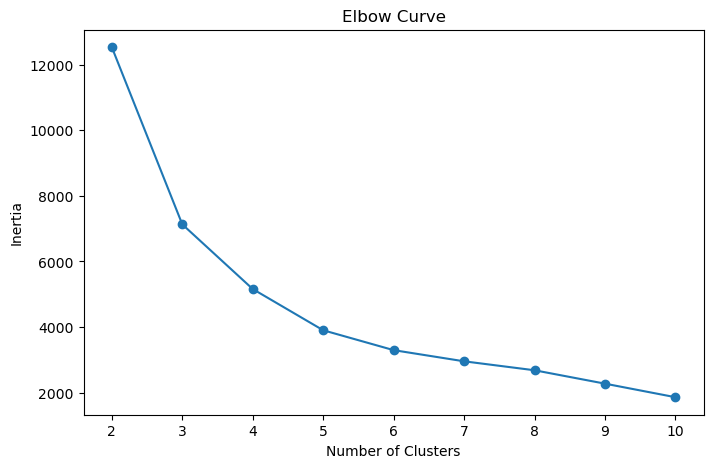

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

The Elbow Curve was used to determine the optimal number of clusters. The inertia decreases rapidly until K=5, after which the rate of decrease becomes much slower. This indicates that K=5 provides a good balance between cluster compactness and model complexity. Therefore, K=5 was selected as a candidate for customer segmentation.

In [13]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        "K =",k,
        "Score =",round(score,3)
    )

K = 2 Score = 0.556
K = 3 Score = 0.583
K = 4 Score = 0.59
K = 5 Score = 0.601
K = 6 Score = 0.55
K = 7 Score = 0.55
K = 8 Score = 0.485
K = 9 Score = 0.503
K = 10 Score = 0.504


The Silhouette Score was calculated for different values of K. The highest score (0.601) was obtained at K=5, indicating better cluster separation and cohesion compared to other cluster configurations.

In [19]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    X_scaled
)

In [20]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346,326,12,77556.46,1
1,12347,2,8,4921.53,4
2,12348,75,5,2019.40,4
3,12349,19,4,4428.69,4
4,12350,310,1,334.40,0


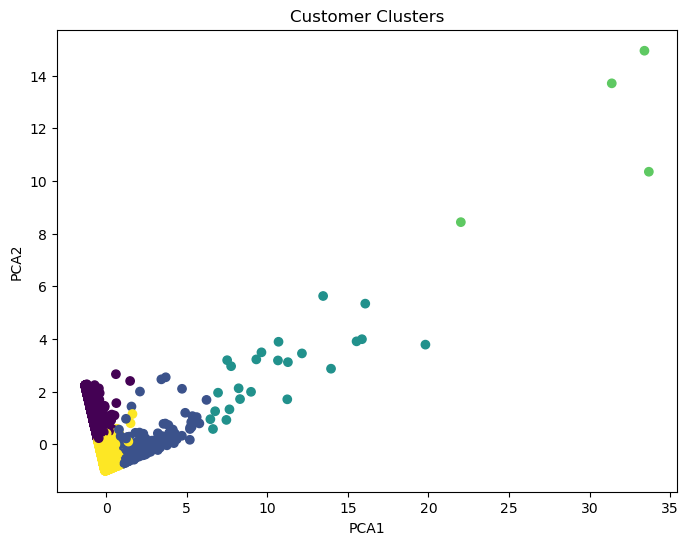

In [21]:
pca_df['Cluster'] = rfm['Cluster']

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    c=pca_df['Cluster']
)

plt.title("Customer Clusters")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

In [22]:
cluster_summary = rfm.groupby(
    'Cluster'
)[['Recency',
   'Frequency',
   'Monetary'
]].mean()

print(cluster_summary)

            Recency   Frequency       Monetary
Cluster                                       
0        471.227439    2.166406     738.564064
1         28.055263   28.618421   13662.778158
2         22.458333  119.791667   98956.849167
3          3.500000  212.500000  428611.997500
4         75.674641    5.126935    1879.456479


Understanding RFM Metrics

Recency: Lower values indicate that a customer has made a purchase recently.

Frequency: Higher values indicate that a customer purchases more often.
    
Monetary: Higher values indicate that a customer spends more money.

Business Recommendations :

Recommendation 1

Offer loyalty rewards, exclusive discounts, and early-access promotions to VIP Loyal Customers (Cluster 3) to strengthen customer retention and maintain long-term engagement.

Recommendation 2

Implement personalized marketing campaigns and premium product recommendations for High-Value Customers (Cluster 2) to increase customer lifetime value and maximize revenue.

Recommendation 3

Launch re-engagement campaigns, targeted discounts, or special promotional offers for Inactive Customers (Cluster 0) to encourage repeat purchases and reduce customer churn.